# 9-1. 들어가며

## 루브릭(평가문항)
1. 프로젝트 1, 2를 정상적인 흐름대로 진행하였는가?
    - 데이터 라벨링 방법 4가지 및 각종 지표를 적용한 데이터셋을 활용하여 특성선택을 시도하였다.
2. 프로젝트 3에서 다양한 방법을 사용하여 기존의 결과와 비교 분석 시도하였는가?
    - PKFold의 split 개수, 데이터 비율, 데이터 개수 등의 파라미터 변경 및 모델 변경을 시도하고 기존의 결과와 비교하였다.
3. 다양한 방법을 사용하여 성능향상을 시도하였는가?
    - classification report에서 accuracy, precision, recall의 성능을 5% 이상 향상 시켰다.

# 9-2. Data Labeling

## Package Import

In [1]:
import sys
print(sys.executable)
print('\n'.join(sys.path[:5]))

d:\pytest\260224_ts_05_Finance_Time_Series_Data_mq\venv\Scripts\python.exe
C:\Users\zuser\AppData\Local\Programs\Python\Python311\python311.zip
C:\Users\zuser\AppData\Local\Programs\Python\Python311\DLLs
C:\Users\zuser\AppData\Local\Programs\Python\Python311\Lib
C:\Users\zuser\AppData\Local\Programs\Python\Python311
d:\pytest\260224_ts_05_Finance_Time_Series_Data_mq\venv


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
# CPU 코어 수를 자동으로 감지하여 병렬 처리에 사용
N_JOBS = os.cpu_count() if os.cpu_count() is not None else 1
# 감지된 코어 수를 출력
print(f'Available CPU cores: {N_JOBS}')


Available CPU cores: 20


## Data Loading

<Axes: xlabel='time'>

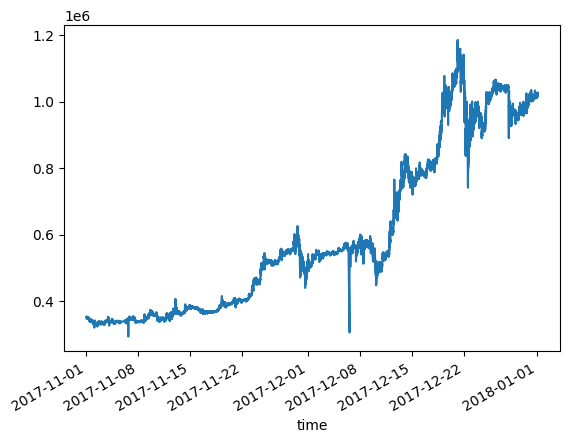

In [3]:
# 이 데이터는 17년 11월 12월 2달간의 변화 close는 종가
# DATA_PATH = '/aiffel/aiffel/fnguide/data/'
# modify_data = pd.read_csv(os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv'), index_col=0, parse_dates=True)
# modify_data.loc['2017-11-01':'2017-12-31','close'].plot()

modify_data = pd.read_csv(('sub_upbit_eth_min_tick.csv'), index_col=0, parse_dates=True)
modify_data.loc['2017-11-01':'2017-12-31','close'].plot()

## 2. Data Labeling

### 1 Price Change Direction

In [4]:
window = 10
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].shift(window)) + 1)
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index)

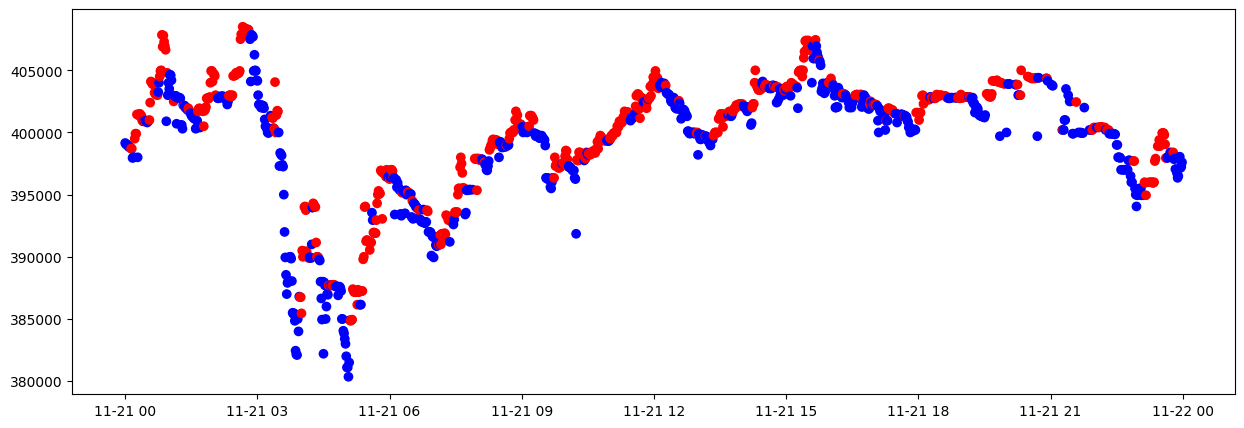

In [5]:
sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = s_momentum_signal.loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

plt.figure(figsize=(15,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

In [6]:
s_momentum_signal

time
2017-09-25 03:00:00    NaN
2017-09-25 03:01:00    NaN
2017-09-25 03:02:00    NaN
2017-09-25 03:05:00    NaN
2017-09-25 03:06:00    NaN
                      ... 
2019-11-03 10:29:00    1.0
2019-11-03 10:30:00    0.0
2019-11-03 10:31:00    0.0
2019-11-03 10:32:00    0.0
2019-11-03 10:33:00    0.0
Name: close, Length: 1000000, dtype: float64

### 2 Using Moving Average

In [7]:
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].rolling(window).mean()) + 1)
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index)

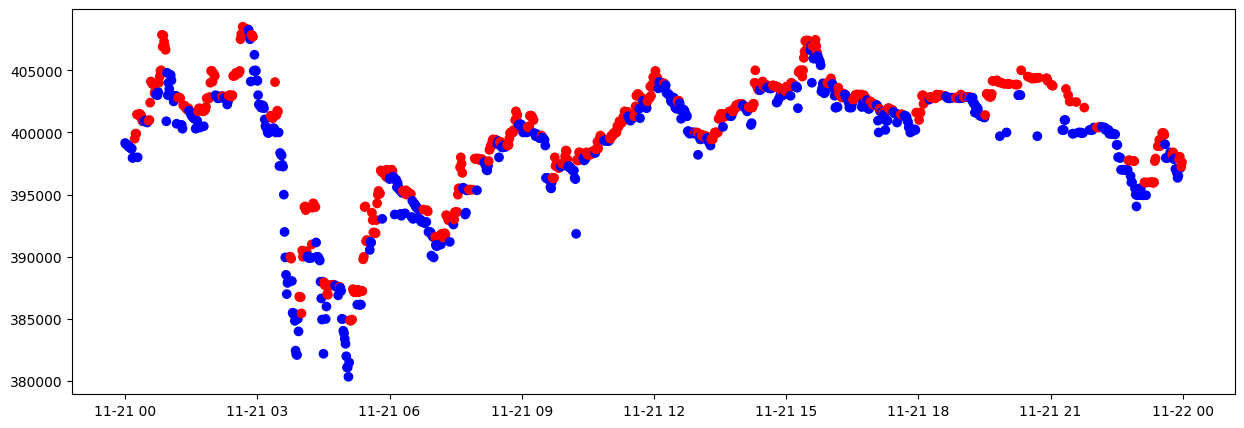

In [8]:
sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = s_momentum_signal.loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

plt.figure(figsize=(15,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

In [9]:
s_momentum_signal

time
2017-09-25 03:00:00    NaN
2017-09-25 03:01:00    NaN
2017-09-25 03:02:00    NaN
2017-09-25 03:05:00    NaN
2017-09-25 03:06:00    NaN
                      ... 
2019-11-03 10:29:00    0.0
2019-11-03 10:30:00    0.0
2019-11-03 10:31:00    0.0
2019-11-03 10:32:00    0.0
2019-11-03 10:33:00    0.0
Name: close, Length: 1000000, dtype: float64

### 3 Local Min-Max

In [10]:
# Local min / max 를 추출하기 위한 함수
def get_local_min_max(close, wait=3):
    min_value = close.iloc[0]
    max_value = close.iloc[0]
    n_cnt_min, n_cnt_max = 0, 0

    mins, maxes = [], []
    min_idxes, max_idxes = [], []
    b_min_update, b_max_update = False, False

    for idx, val in zip(close.index[1:], close.values[1:]):
        if val < min_value:
            min_value = val
            mins.append(min_value)
            min_idxes.append(idx)
            n_cnt_min = 0
            b_min_update = True
        if val > max_value:
            max_value = val
            maxes.append(max_value)
            max_idxes.append(idx)
            n_cnt_max = 0
            b_max_update = True

        if not b_max_update:
            b_min_update = False
            n_cnt_min += 1
            if n_cnt_min >= wait:
                max_value = min_value
                n_cnt_min = 0

        if not b_min_update:
            b_max_update = False
            n_cnt_max += 1
            if n_cnt_max >= wait:
                min_value = max_value
                n_cnt_max = 0

    return pd.DataFrame.from_dict({'min_time': min_idxes, 'local_min': mins}), pd.DataFrame.from_dict({'max_time': max_idxes, 'local_max': maxes})

In [11]:
mins, maxes = get_local_min_max(sub_data, wait=3)

(376546.5, 412585.0)

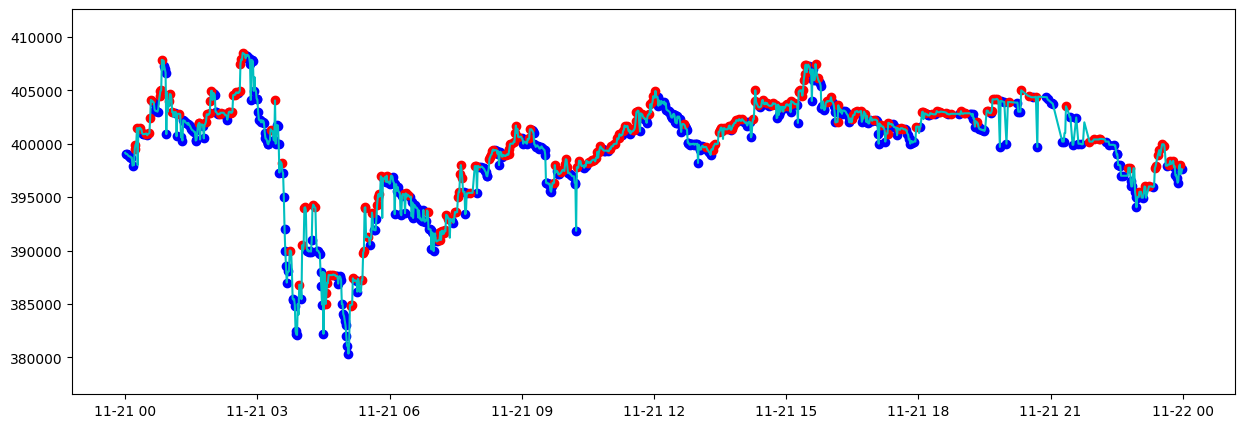

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(sub_data, 'c')
ax.scatter(mins.min_time, mins.local_min, c='blue')
ax.scatter(maxes.max_time, maxes.local_max, c='red')
ax.set_ylim([sub_data.min() * 0.99, sub_data.max()  * 1.01])

(376546.5, 412585.0)

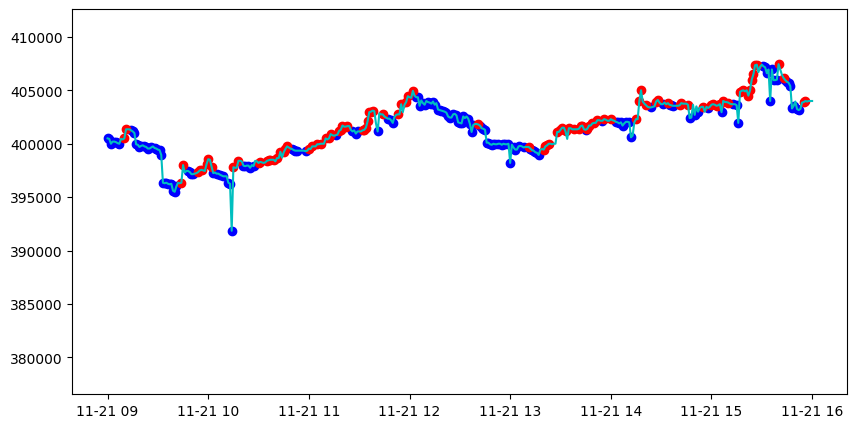

In [13]:
st_time, ed_time = '2017-11-21 09:00:00', '2017-11-21 16:00:00'

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(sub_data.loc[st_time:ed_time], 'c')
ax.scatter(mins.set_index('min_time', drop=False).min_time.loc[st_time:ed_time], mins.set_index('min_time').local_min.loc[st_time:ed_time], c='blue')
ax.scatter(maxes.set_index('max_time', drop=False).max_time.loc[st_time:ed_time], maxes.set_index('max_time').local_max.loc[st_time:ed_time], c='red')
ax.set_ylim([sub_data.min() * 0.99, sub_data.max()  * 1.01])

In [14]:
mins.shape[0], maxes.shape[0]

(477, 273)

### 4 Trend Scanning

In [15]:
# 선형회귀 기울기의 t-value를 빠르게 계산하는 함수 정의
def t_val_lin_r(close_values):    
    y = np.asarray(close_values, dtype=np.float64)# 입력값을 float 배열로 변환    
    n = y.shape[0]# 표본 길이 계산
    
    if n < 3:  # 표본 길이가 3 미만이면 유효한 t-value 계산이 불가하므로 0 반환
        return 0.0
    
    x = np.arange(n, dtype=np.float64)# 시간축 x를 0부터 n-1까지 생성    
    x_mean = x.mean() # x,y 평균 계산    
    y_mean = y.mean()
    
    sxx = np.sum((x - x_mean) ** 2) # 분산 항(Sxx) 계산    
    if sxx == 0.0: # Sxx가 0이면 분모가 0이 되므로 0 반환
        return 0.0
    
    sxy = np.sum((x - x_mean) * (y - y_mean)) # 공분산 항(Sxy) 계산    
    beta1 = sxy / sxx # 기울기(beta1) 계산    
    beta0 = y_mean - beta1 * x_mean # 절편(beta0) 계산    
    y_hat = beta0 + beta1 * x # 예측값 계산    
    residual = y - y_hat # 잔차 계산    
    dof = n - 2 # 자유도 계산
    
    if dof <= 0: # 자유도가 0 이하면 0 반환
        return 0.0
    
    s_err = np.sqrt(np.sum(residual ** 2) / dof) # 잔차 표준오차 계산    
    se_beta1 = s_err / np.sqrt(sxx) # 기울기 표준오차 계산
    
    if se_beta1 == 0.0: # 표준오차 0이면 0 반환
        return 0.0
    
    return beta1 / se_beta1 # 기울기 t-value를 반환


In [16]:
look_forward_window = 60
min_sample_length = 5
step = 1
t1_array = []
t_values_array = []

In [17]:
# 트렌드 스캐닝 윈도우 내 최적 t-value 찾는 함수 정의
def trend_scan_one(start_pos, close_array, index_array, look_forward_window=60, min_sample_length=5):    
    end_pos = start_pos + look_forward_window # 전방 탐색 종료 위치를 계산    
    if end_pos > len(close_array): # 데이터 길이를 넘어가면 None 반환
        return None
    
    subset = close_array[start_pos:end_pos] # 현재 시작점 기준의 전방 구간 데이터를 추출    
    best_t = 0.0 # 최적 t-value를 저장할 변수 초기화    
    for fw in range(min_sample_length, len(subset) + 1): # 최소 길이부터 순차적으로 구간을 확장하며 t-value 계산        
        cur_t = t_val_lin_r(subset[:fw]) # 부분 구간 t-value를 계산        
        if abs(cur_t) > abs(best_t): # 절댓값 기준으로 더 큰 t-value면 갱신
            best_t = cur_t
    
    t1 = index_array[end_pos - 1] # 라벨 종료 시점을 저장    
    bin_value = np.sign(best_t) # 방향 라벨(-1, 0, 1)을 계산    
    return t1, best_t, bin_value # 결과를 튜플로 반환


molecule = modify_data['2017-11-01':'2017-11-30'].index # 라벨링 대상 구간 인덱스를 선택
close_array = modify_data['close'].to_numpy(dtype=np.float64) # 전체 close 시계열을 배열로 변환
index_array = modify_data.index.to_numpy() # 전체 인덱스를 배열로 변환
start_positions = modify_data.index.get_indexer(molecule) # 시작 인덱스 위치 계산
valid_mask = (start_positions >= 0) & ((start_positions + look_forward_window) <= len(close_array)) # 유효한 시작 위치만 필터링
valid_positions = start_positions[valid_mask] # 유효 시작 위치를 추출
valid_index = molecule[valid_mask] # 유효 인덱스를 추출


from joblib import Parallel, delayed # 멀티코어 병렬 처리를 위한 모듈
# 병렬로 트렌드 스캐닝 라벨을 생성
tmp_out = Parallel(n_jobs=N_JOBS, prefer='processes')(
    delayed(trend_scan_one)(pos, close_array, index_array, look_forward_window, min_sample_length)
    for pos in tqdm(valid_positions)
)

label = pd.DataFrame(tmp_out, index=valid_index, columns=['t1', 't_val', 'bin'])
label['t1'] = pd.to_datetime(label['t1'])
label['bin'] = pd.to_numeric(label['bin'], downcast='signed')


100%|██████████| 33384/33384 [00:05<00:00, 6181.55it/s]


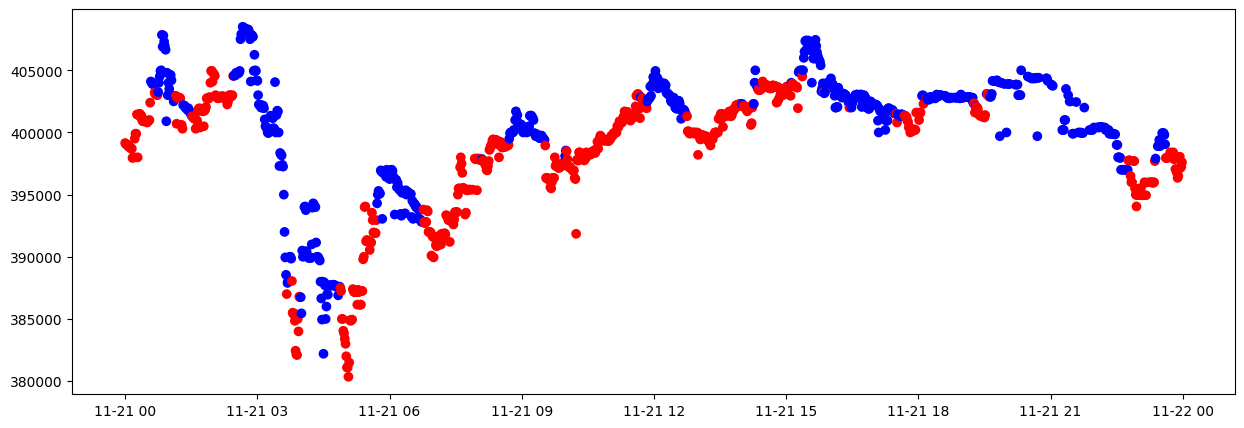

In [18]:
sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = label['bin'].loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.scatter(sub_data.index, sub_data.values, c=c_sig['color'])

In [19]:
label

,t1,t_val,bin
time,,,
2017-11-01 00:05:00,2017-11-01 06:16:00,-6.373987,-1
2017-11-01 00:12:00,2017-11-01 06:23:00,-6.273936,-1
2017-11-01 00:18:00,2017-11-01 06:29:00,-5.897474,-1
2017-11-01 00:24:00,2017-11-01 06:35:00,-5.425023,-1
2017-11-01 00:31:00,2017-11-01 06:42:00,-5.081770,-1
...,...,...,...
2017-11-30 23:55:00,2017-12-01 00:55:00,-7.335637,-1
2017-11-30 23:56:00,2017-12-01 00:56:00,-7.783159,-1
2017-11-30 23:57:00,2017-12-01 00:57:00,-8.243417,-1


# 9-3. Feature Engineering

## 1. 환경구성 및 데이터 불러오기

In [20]:
# 패키지 설치는 노트북 내부가 아닌 requirements.txt로 진행

In [21]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

from sklearn.feature_selection import SequentialFeatureSelector, RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# CPU 코어 수를 병렬 처리에 사용
N_JOBS = os.cpu_count() if os.cpu_count() is not None else 1


In [40]:
"""
mlfinlab
"""

"""
Module which implements feature importance algorithms as described in Chapter 8 of Advances in Financial Machine
Learning and Clustered Feature Importance algorithms as described in Chapter 6 Section 6.5.2 of Machine Learning for
Asset Managers.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import log_loss


def mean_decrease_impurity(model, feature_names, clustered_subsets=None):
    """
    Advances in Financial Machine Learning, Snippet 8.2, page 115.
    MDI Feature importance
    Mean decrease impurity (MDI) is a fast, explanatory-importance (in-sample, IS) method specific to tree-based
    classifiers, like RF. At each node of each decision tree, the selected feature splits the subset it received in
    such a way that impurity is decreased. Therefore, we can derive for each decision tree how much of the overall
    impurity decrease can be assigned to each feature. And given that we have a forest of trees, we can average those
    values across all estimators and rank the features accordingly.
    Tip:
    Masking effects take place when some features are systematically ignored by tree-based classifiers in favor of
    others. In order to avoid them, set max_features=int(1) when using sklearn’s RF class. In this way, only one random
    feature is considered per level.
    Notes:
    * MDI cannot be generalized to other non-tree based classifiers
    * The procedure is obviously in-sample.
    * Every feature will have some importance, even if they have no predictive power whatsoever.
    * MDI has the nice property that feature importances add up to 1, and every feature importance is bounded between 0 and 1.
    * method does not address substitution effects in the presence of correlated features. MDI dilutes the importance of
      substitute features, because of their interchangeability: The importance of two identical features will be halved,
      as they are randomly chosen with equal probability.
    * Sklearn’s RandomForest class implements MDI as the default feature importance score. This choice is likely
      motivated by the ability to compute MDI on the fly, with minimum computational cost.
    Clustered Feature Importance( Machine Learning for Asset Manager snippet 6.4 page 86) :
    Clustered MDI  is the  modified version of MDI (Mean Decreased Impurity). It  is robust to substitution effect that
    takes place when two or more explanatory variables share a substantial amount of information (predictive power).CFI
    algorithm described by Dr Marcos Lopez de Prado  in Clustered Feature  Importance section of book Machine Learning
    for Asset Manager. Here  instead of  taking the importance  of  every feature, we consider the importance of every
    feature subsets, thus every feature receive the importance of subset it belongs to.
    :param model: (model object): Trained tree based classifier.
    :param feature_names: (list): Array of feature names.
    :param clustered_subsets: (list) Feature clusters for Clustered Feature Importance (CFI). Default None will not apply CFI.
                              Structure of the input must be a list of list/s i.e. a list containing the clusters/subsets of feature
                              name/s inside a list. E.g- [['I_0','I_1','R_0','R_1'],['N_1','N_2'],['R_3']]
    :return: (pd.DataFrame): Mean and standard deviation feature importance.
    """
    # Feature importance based on in-sample (IS) mean impurity reduction
    feature_imp_df = {i: tree.feature_importances_ for i, tree in enumerate(model.estimators_)}
    feature_imp_df = pd.DataFrame.from_dict(feature_imp_df, orient='index')
    feature_imp_df.columns = feature_names

    # Make sure that features with zero importance are not averaged, since the only reason for a 0 is that the feature
    # was not randomly chosen. Replace those values with np.nan
    feature_imp_df = feature_imp_df.replace(0, np.nan)  # Because max_features = 1

    if clustered_subsets is not None:
        # Getting subset wise importance
        importance = pd.DataFrame(index=feature_names, columns=['mean', 'std'])
        for subset in clustered_subsets: # Iterating over each cluster
            subset_feat_imp = feature_imp_df[subset].sum(axis=1)
            # Importance of each feature within a subsets is equal to the importance of that subset
            importance.loc[subset, 'mean'] = subset_feat_imp.mean()
            importance.loc[subset, 'std'] = subset_feat_imp.std()*subset_feat_imp.shape[0]**-.5
    else:
        importance = pd.concat({'mean': feature_imp_df.mean(),
                                'std': feature_imp_df.std() * feature_imp_df.shape[0] ** -0.5},
                               axis=1)

    importance /= importance['mean'].sum()
    return importance


def mean_decrease_accuracy(model, X, y, cv_gen, clustered_subsets=None, sample_weight_train=None,
                           sample_weight_score=None, scoring=log_loss, random_state=42):
    """
    Advances in Financial Machine Learning, Snippet 8.3, page 116-117.
    MDA Feature Importance
    Mean decrease accuracy (MDA) is a slow, predictive-importance (out-of-sample, OOS) method. First, it fits a
    classifier; second, it derives its performance OOS according to some performance score (accuracy, negative log-loss,
    etc.); third, it permutates each column of the features matrix (X), one column at a time, deriving the performance
    OOS after each column’s permutation. The importance of a feature is a function of the loss in performance caused by
    its column’s permutation. Some relevant considerations include:
    * This method can be applied to any classifier, not only tree-based classifiers.
    * MDA is not limited to accuracy as the sole performance score. For example, in the context of meta-labeling
      applications, we may prefer to score a classifier with F1 rather than accuracy. That is one reason a better
      descriptive name would have been “permutation importance.” When the scoring function does not correspond to a
      metric space, MDA results should be used as a ranking.
    * Like MDI, the procedure is also susceptible to substitution effects in the presence of correlated features.
      Given two identical features, MDA always considers one to be redundant to the other. Unfortunately, MDA will make
      both features appear to be outright irrelevant, even if they are critical.
    * Unlike MDI, it is possible that MDA concludes that all features are unimportant. That is because MDA is based on
      OOS performance.
    * The CV must be purged and embargoed.
    Clustered Feature Importance( Machine Learning for Asset Manager snippet 6.5 page 87) :
    Clustered MDA is the modified version of MDA (Mean Decreased Accuracy). It is robust to substitution effect that takes
    place when two or more explanatory variables share a substantial amount of information (predictive power).CFI algorithm
    described by Dr Marcos Lopez de Prado  in Clustered Feature  Importance (Presentation Slides)
    https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3517595. Instead of shuffling (permutating) all variables
    individually (like in MDA), we shuffle all variables in cluster together. Next, we follow all the  rest of the
    steps as in MDA. It can used by simply specifying the clustered_subsets argument.
    :param model: (sklearn.Classifier): Any sklearn classifier.
    :param X: (pd.DataFrame): Train set features.
    :param y: (pd.DataFrame, np.array): Train set labels.
    :param cv_gen: (cross_validation.PurgedKFold): Cross-validation object.
    :param clustered_subsets: (list) Feature clusters for Clustered Feature Importance (CFI). Default None will not apply CFI.
                              Structure of the input must be a list of list/s i.e. a list containing the clusters/subsets of feature
                              name/s inside a list. E.g- [['I_0','I_1','R_0','R_1'],['N_1','N_2'],['R_3']]
    :param sample_weight_train: (np.array) Sample weights used to train the model for each record in the dataset.
    :param sample_weight_score: (np.array) Sample weights used to evaluate the model quality.
    :param scoring: (function): Scoring function used to determine importance.
    :param random_state: (int) Random seed for shuffling the features.
    :return: (pd.DataFrame): Mean and standard deviation of feature importance.
    """

    if sample_weight_train is None:
        sample_weight_train = np.ones((X.shape[0],))

    if sample_weight_score is None:
        sample_weight_score = np.ones((X.shape[0],))

    fold_metrics_values, features_metrics_values = pd.Series(dtype='float64'), pd.DataFrame(columns=X.columns)
    # Generating a numpy random state object for the given random_state
    rs_obj = np.random.RandomState(seed=random_state)
    # Clustered feature subsets will be used for CFI if clustered_subsets exists else will operate on the single column as MDA
    feature_sets = clustered_subsets if clustered_subsets else [[x] for x in X.columns]
    for i, (train, test) in enumerate(cv_gen.split(X=X)):
        fit = model.fit(X=X.iloc[train, :], y=y.iloc[train], sample_weight=sample_weight_train[train])
        pred = fit.predict(X.iloc[test, :])

        # Get overall metrics value on out-of-sample fold
        if scoring == log_loss:
            prob = fit.predict_proba(X.iloc[test, :])
            fold_metrics_values.loc[i] = -scoring(y.iloc[test], prob, sample_weight=sample_weight_score[test],
                                                  labels=model.classes_)
        else:
            fold_metrics_values.loc[i] = scoring(y.iloc[test], pred, sample_weight=sample_weight_score[test])

        # Get feature specific metric on out-of-sample fold
        for j in feature_sets:
            X1_ = X.iloc[test, :].copy(deep=True)
            for j_i in j:
                rs_obj.shuffle(X1_[j_i].values)  # Permutation of a single column for MDA or through the whole subset for CFI
            if scoring == log_loss:
                prob = fit.predict_proba(X1_)
                features_metrics_values.loc[i, j] = -scoring(y.iloc[test], prob,
                                                             sample_weight=sample_weight_score[test],
                                                             labels=model.classes_)
            else:
                pred = fit.predict(X1_)
                features_metrics_values.loc[i, j] = scoring(y.iloc[test], pred,
                                                            sample_weight=sample_weight_score[test])

    importance = (-features_metrics_values).add(fold_metrics_values, axis=0)
    if scoring == log_loss:
        importance = importance / -features_metrics_values
    else:
        importance = importance / (1.0 - features_metrics_values).replace(0, np.nan)
    importance = pd.concat({'mean': importance.mean(), 'std': importance.std() * importance.shape[0] ** -.5}, axis=1)
    importance.replace([-np.inf, np.nan], 0, inplace=True)  # Replace infinite values

    return importance

In [41]:
DATA_PATH = '.'
anno_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick_label.pkl')
target_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv')

In [42]:
df_modify_data = pd.read_csv(target_file_name, index_col=0, parse_dates=True)
df_label_data = pd.read_pickle(anno_file_name)
df_sub_modify_data = df_modify_data.loc[df_label_data.index]

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옴
df_sub_modify_data = df_sub_modify_data.iloc[:1000]

In [43]:
df_sub_modify_data

,open,high,low,close,volume
time,,,,,
2018-01-01 00:00:00,1028000,1028000,1026500,1028000,41.835689
2018-01-01 00:01:00,1028000,1029000,1026000,1028500,22.307810
2018-01-01 00:02:00,1028000,1029000,1028000,1028000,59.276102
2018-01-01 00:03:00,1028000,1028000,1014000,1014000,114.203740
2018-01-01 00:04:00,1020000,1027000,1014500,1025000,62.695404
...,...,...,...,...,...
2018-01-01 16:35:00,1052500,1052500,1052500,1052500,6.084122
2018-01-01 16:36:00,1052500,1052500,1049500,1050000,9.205537
2018-01-01 16:37:00,1050000,1050000,1049000,1049000,3.472849


In [44]:
df_label_data.head(), df_label_data.tail()

(time
 2018-01-01 00:00:00   -0.0
 2018-01-01 00:01:00   -0.0
 2018-01-01 00:02:00   -0.0
 2018-01-01 00:03:00   -1.0
 2018-01-01 00:04:00   -1.0
 Name: t_value, dtype: float64,
 time
 2019-11-03 10:29:00   NaN
 2019-11-03 10:30:00   NaN
 2019-11-03 10:31:00   NaN
 2019-11-03 10:32:00   NaN
 2019-11-03 10:33:00   NaN
 Name: t_value, dtype: float64)

In [45]:
df_label_data.value_counts()

-1.0    306636
-0.0    302963
 1.0    299289
Name: t_value, dtype: int64

In [46]:
df_label_data.value_counts()

-1.0    306636
-0.0    302963
 1.0    299289
Name: t_value, dtype: int64

## 2. Technical Index

In [47]:
mt = 1
fillna = False
df_ = df_sub_modify_data.copy()
open, high, low, close, volume = 'open', 'high', 'low', 'close', 'volume'
cols = [open, high, low, close, volume]

## Volume Index
# Chaikin Money Flow
df_["volume_cmf"] = ta.volume.ChaikinMoneyFlowIndicator(
                        high=df_[high], low=df_[low], close=df_[close], volume=df_[volume], window=20*mt, fillna=fillna
                    ).chaikin_money_flow()
# Force Index
df_["volume_fi"] = ta.volume.ForceIndexIndicator(
                        close=df_[close], volume=df_[volume], window=15*mt, fillna=fillna
                    ).force_index()
# Money Flow Indicator
df_["volume_mfi"] = ta.volume.MFIIndicator(
                        high=df_[high],
                        low=df_[low],
                        close=df_[close],
                        volume=df_[volume],
                        window=15*mt,
                        fillna=fillna,
                    ).money_flow_index()
# Ease of Movement
df_["volume_sma_em"] = ta.volume.EaseOfMovementIndicator(
                            high=df_[high], low=df_[low], volume=df_[volume], window=15*mt, fillna=fillna
                        ).sma_ease_of_movement()

# Volume Price Trend
df_["volume_vpt"] = ta.volume.VolumePriceTrendIndicator(
                        close=df_[close], volume=df_[volume], fillna=fillna
                    ).volume_price_trend()

## volatility index
# Average True Range
df_["volatility_atr"] = ta.volatility.AverageTrueRange(
                            close=df_[close], high=df_[high], low=df_[low], window=10*mt, fillna=fillna
                        ).average_true_range()

# Ulcer Index
df_["volatility_ui"] = ta.volatility.UlcerIndex(
                            close=df_[close], window=15*mt, fillna=fillna
                        ).ulcer_index()

## trend index
# MACD
df_["trend_macd_diff"] = ta.trend.MACD(
                            close=df_[close], window_slow=25*mt, window_fast=10*mt, window_sign=9, fillna=fillna
                        ).macd_diff()

# Average Directional Movement Index (ADX)
df_["trend_adx"] = ta.trend.ADXIndicator(
                        high=df_[high], low=df_[low], close=df_[close], window=15*mt, fillna=fillna
                    ).adx()

# TRIX Indicator
df_["trend_trix"] = ta.trend.TRIXIndicator(
                        close=df_[close], window=15*mt, fillna=fillna
                    ).trix()

# Mass Index
df_["trend_mass_index"] = ta.trend.MassIndex(
                            high=df_[high], low=df_[low], window_fast=10*mt, window_slow=25*mt, fillna=fillna
                        ).mass_index()

# DPO Indicator
df_["trend_dpo"] = ta.trend.DPOIndicator(
                        close=df_[close], window=20*mt, fillna=fillna
                    ).dpo()

# Aroon Indicator
df_["trend_aroon_ind"] = ta.trend.AroonIndicator(close=df_[close], window=20, fillna=fillna).aroon_indicator()

## momentum index
# Relative Strength Index (RSI)
df_["momentum_rsi"] = ta.momentum.RSIIndicator(close=df_[close], window=15*mt, fillna=fillna).rsi()

# Williams R Indicator
df_["momentum_wr"] = ta.momentum.WilliamsRIndicator(
                        high=df_[high], low=df_[low], close=df_[close], lbp=15*mt, fillna=fillna
                    ).williams_r()

In [48]:
# 결과 확인
df_

,open,high,low,close,volume,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,trend_mass_index,trend_dpo,trend_aroon_ind,momentum_rsi,momentum_wr
time,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,1028000,1028000,1026500,1028000,41.835689,NaN,NaN,NaN,NaN,-0.796083,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:01:00,1028000,1029000,1026000,1028500,22.307810,NaN,NaN,NaN,NaN,-0.788285,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:02:00,1028000,1029000,1028000,1028000,59.276102,NaN,NaN,NaN,NaN,-0.017967,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:03:00,1028000,1028000,1014000,1014000,114.203740,NaN,NaN,NaN,NaN,-1.584121,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:04:00,1020000,1027000,1014500,1025000,62.695404,NaN,NaN,NaN,NaN,-0.875176,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 16:35:00,1052500,1052500,1052500,1052500,6.084122,-0.232633,-2275.848327,71.279251,-3.186964e+12,0.007381,1416.425464,0.361107,652.357742,20.661135,-0.018034,23.066052,-225.0,-35.0,52.934202,-0.0
2018-01-01 16:36:00,1052500,1052500,1049500,1050000,9.205537,-0.165805,-4868.097577,67.762226,-3.097651e+12,-0.021866,1574.782918,0.349329,482.768654,21.007559,-0.016660,23.029259,-2100.0,-35.0,44.041843,-62.5
2018-01-01 16:37:00,1050000,1050000,1049000,1049000,3.472849,-0.161093,-4693.691500,74.267351,-5.977131e+12,-0.025173,1517.304626,0.342452,280.010175,21.537826,-0.015683,22.971985,-1925.0,-35.0,41.083991,-87.5


In [49]:
windows_mom = [5, 10, 20]
windows_std = [30]

for i in windows_mom:
    df_[f'vol_change_{i}'] = df_.volume.pct_change(i).round(6)
    df_[f'ret_{i}'] = df_.close.pct_change(i).round(6)

for i in windows_std:
    df_[f'std_{i}'] = df_.close.rolling(i).std()
    df_[f'vol_std_{i}'] = df_.volume.rolling(i).std()

In [50]:
# 결과 확인
df_

,open,high,low,close,volume,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,1028000,1028000,1026500,1028000,41.835689,NaN,NaN,NaN,NaN,-0.796083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:01:00,1028000,1029000,1026000,1028500,22.307810,NaN,NaN,NaN,NaN,-0.788285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:02:00,1028000,1029000,1028000,1028000,59.276102,NaN,NaN,NaN,NaN,-0.017967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:03:00,1028000,1028000,1014000,1014000,114.203740,NaN,NaN,NaN,NaN,-1.584121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:04:00,1020000,1027000,1014500,1025000,62.695404,NaN,NaN,NaN,NaN,-0.875176,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 16:35:00,1052500,1052500,1052500,1052500,6.084122,-0.232633,-2275.848327,71.279251,-3.186964e+12,0.007381,...,52.934202,-0.0,-0.817192,0.002381,-0.265538,0.003815,0.703781,0.000000,1811.600550,15.025354
2018-01-01 16:36:00,1052500,1052500,1049500,1050000,9.205537,-0.165805,-4868.097577,67.762226,-3.097651e+12,-0.021866,...,44.041843,-62.5,0.394890,0.000000,0.274989,0.001431,-0.625893,-0.002375,1787.568824,9.944774
2018-01-01 16:37:00,1050000,1050000,1049000,1049000,3.472849,-0.161093,-4693.691500,74.267351,-5.977131e+12,-0.025173,...,41.083991,-87.5,-0.279019,-0.001903,-0.609186,0.000477,-0.849066,-0.003325,1763.291071,9.932495


In [51]:
df_tmp_data = df_.join(df_label_data).dropna()
X, y = df_tmp_data.iloc[:, 5:-1], df_tmp_data.iloc[:, -1]

sc = StandardScaler()
X_sc = sc.fit_transform(X)
X_sc = pd.DataFrame(X_sc, index=X.index, columns=X.columns)

In [52]:
X_sc.head()

,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1.035464,-0.186753,0.065427,0.391695,0.143181,1.474065,0.054076,0.103695,0.930692,-0.078062,...,-0.141586,0.073599,-0.268825,-0.053926,-0.273922,-0.077989,-0.359687,0.617241,-0.335632,0.273404
2018-01-01 00:44:00,1.054026,0.125880,-0.011156,0.814123,0.544363,1.478520,0.017250,0.639945,0.771813,-0.051294,...,0.344922,1.111779,-0.209690,2.237163,-0.263511,0.036043,-0.266915,0.940844,-0.262646,0.291664
2018-01-01 00:45:00,1.042978,-0.023653,0.063195,1.052689,0.218332,1.290057,-0.020738,0.714133,0.598850,-0.015958,...,0.067032,0.544625,-0.124252,0.554780,-0.278339,0.150308,-0.252720,0.942325,-0.237456,0.301886
2018-01-01 00:46:00,1.016133,0.880060,-0.281931,0.928143,1.068429,1.633699,-0.020738,1.434675,0.454452,0.071047,...,0.783648,1.457839,0.168697,2.536405,-0.228841,0.833801,-0.227291,1.672326,-0.022928,0.256716
2018-01-01 00:47:00,0.893440,0.486864,-0.562722,-0.026395,0.862103,1.942977,0.088583,0.921217,0.319680,0.131133,...,-0.191611,-0.257415,-0.080204,0.402681,-0.380178,0.036276,-0.340320,0.454122,-0.018291,0.317671


In [53]:
X_sc.shape

(957, 23)

In [54]:
# 랜덤포레스트 분류기 생성
rfc = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42, n_jobs=N_JOBS)
# 모델 학습 수행
rfc.fit(X_sc, y)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=20,
                       random_state=42)

## 3. Feature Selection methods

### 1-1. MDI, Mean Decrease Impurity

In [55]:
# feat_imp = imp.mean_decrease_impurity(rfc, X.columns)
feat_imp = mean_decrease_impurity(rfc, X.columns)

In [38]:
feat_imp

,mean,std
volume_cmf,0.048045,0.001278
volume_fi,0.042276,0.001256
volume_mfi,0.045667,0.001395
volume_sma_em,0.037016,0.001112
volume_vpt,0.024804,0.000858
volatility_atr,0.077837,0.001888
volatility_ui,0.049151,0.001394
trend_macd_diff,0.072931,0.002152
trend_adx,0.053880,0.001324
trend_trix,0.070069,0.001723


### 1-2. MDA, Mean Decrease Accuracy

In [ ]:
# RBF SVC 모델을 생성
svc_rbf = SVC(kernel='rbf', probability=True)
# KFold 교차검증 객체를 생성
cv = KFold(n_splits=5, shuffle=False)
# MDA 계산을 수행
feat_imp_mda = mean_decrease_accuracy(svc_rbf, X_sc, y, cv_gen=cv)


In [57]:
def plot_feature_importance(importance_df, save_fig=False, output_path=None):
    # Plot mean imp bars with std
    plt.figure(figsize=(10, importance_df.shape[0] / 5))
    importance_df.sort_values('mean', ascending=True, inplace=True)
    importance_df['mean'].plot(kind='barh', color='b', alpha=0.25, xerr=importance_df['std'], error_kw={'ecolor': 'r'})
    if save_fig:
        plt.savefig(output_path)
    else:
        plt.show()

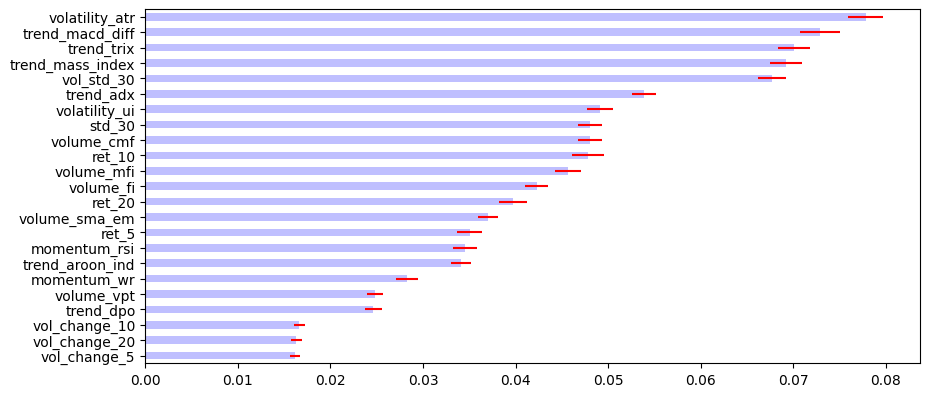

In [58]:
# volatility_atr : 시장의 변동성(진폭)을 측정하는 지표입니다
# Average True Range (ATR)
plot_feature_importance(feat_imp)

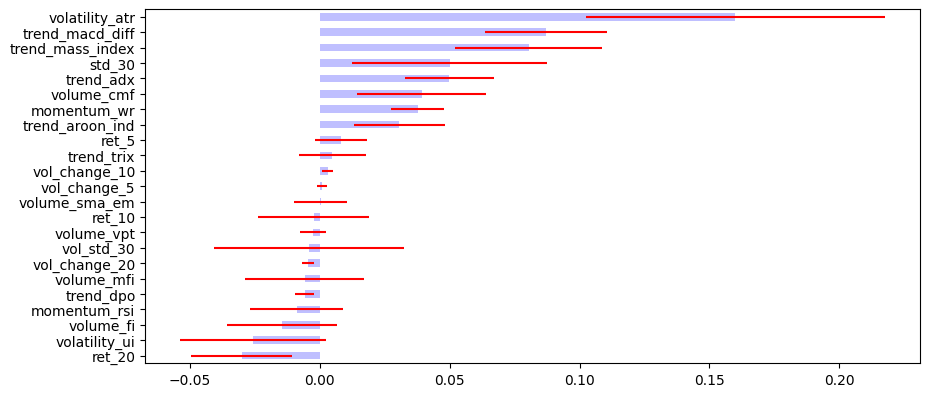

In [59]:
plot_feature_importance(feat_imp_mda)

### 2-1. RFE CV, Recursive Feature Elimination

In [ ]:

svc_rbf = SVC(kernel='linear', probability=True)
rfe_cv = RFECV(svc_rbf, cv=cv, n_jobs=N_JOBS)
rfe_fitted = rfe_cv.fit(X_sc, y)


In [61]:
rfe_df = pd.DataFrame([rfe_fitted.support_, rfe_fitted.ranking_], columns=X_sc.columns).T.rename(columns={0:"Optimal_Features", 1:"Ranking"})
rfe_df

,Optimal_Features,Ranking
volume_cmf,False,12
volume_fi,False,4
volume_mfi,False,14
volume_sma_em,False,7
volume_vpt,False,8
volatility_atr,True,1
volatility_ui,False,11
trend_macd_diff,True,1
trend_adx,False,19
trend_trix,False,10


In [62]:
rfe_df[rfe_df["Optimal_Features"]==True]

,Optimal_Features,Ranking
volatility_atr,True,1
trend_macd_diff,True,1
std_30,True,1


### 2-2. SFS, Sequential Feature Selection

In [63]:
# 선택할 피처 개수를 지정
n = 2
# 순차 전진 선택 객체를 생성
sfs_forward = SequentialFeatureSelector(svc_rbf, n_features_to_select=n, direction='forward', n_jobs=N_JOBS)
# SFS 학습을 수행
sfs_fitted = sfs_forward.fit(X_sc, y)


In [64]:
sfs_rank = sfs_fitted.get_support()

# 최신 버전은 {} 대신 [] 사용
#sfs_df = pd.DataFrame(sfs_rank, index=X_sc.columns, columns={"Optimal_Features"})
sfs_df = pd.DataFrame(sfs_rank, index=X_sc.columns, columns=["Optimal_Features"])

sfs_df [sfs_df ["Optimal_Features"]==True].index

Index(['volume_mfi', 'trend_macd_diff'], dtype='object')

### 2-3. SHAP, Shapley Additive explanations

In [65]:
# SHAP 라이브러리를 임포트
import shap
# 트리 기반 SHAP 설명기 생성
explainer = shap.TreeExplainer(rfc, model_output='raw')
# SHAP 값을 계산
shap_value = explainer.shap_values(X_sc)


In [66]:
shap_value.shape

(957, 23, 3)

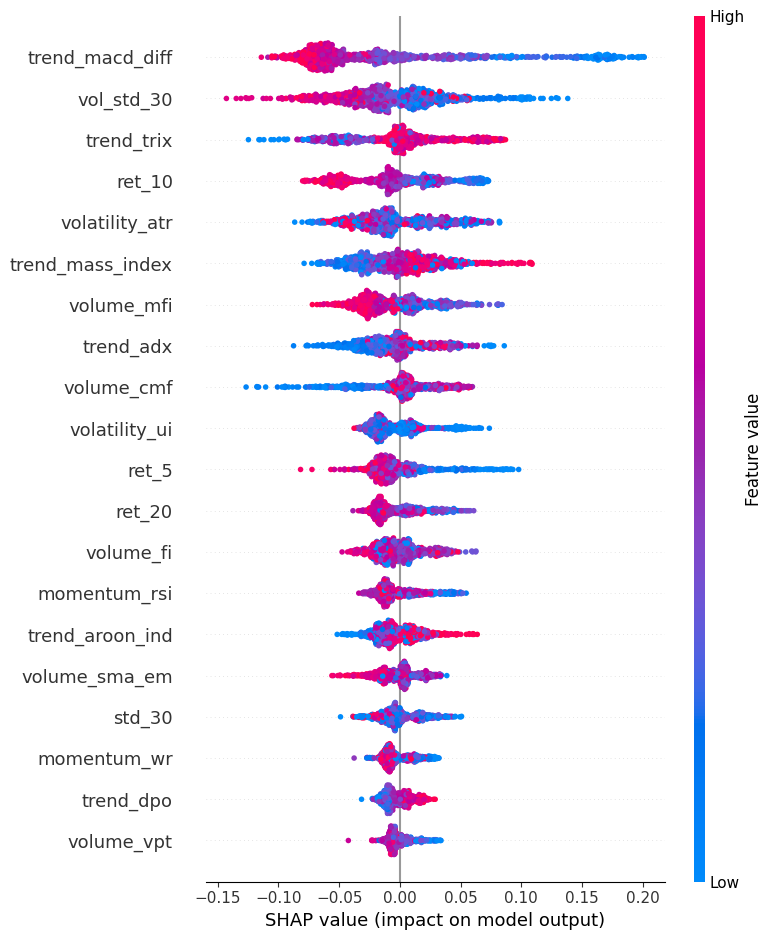

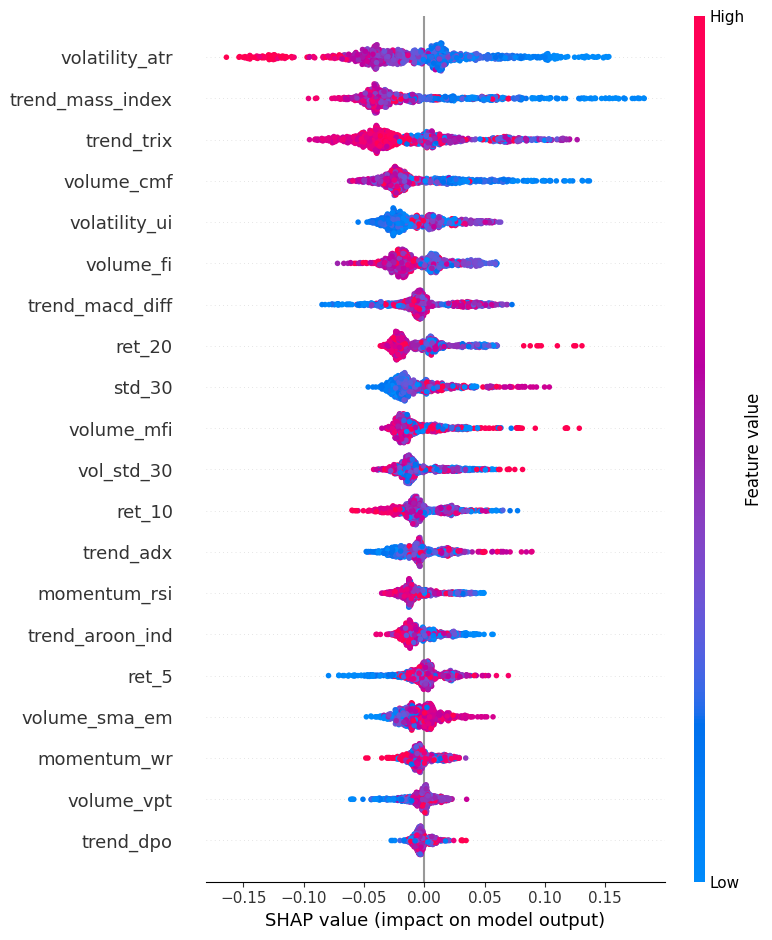

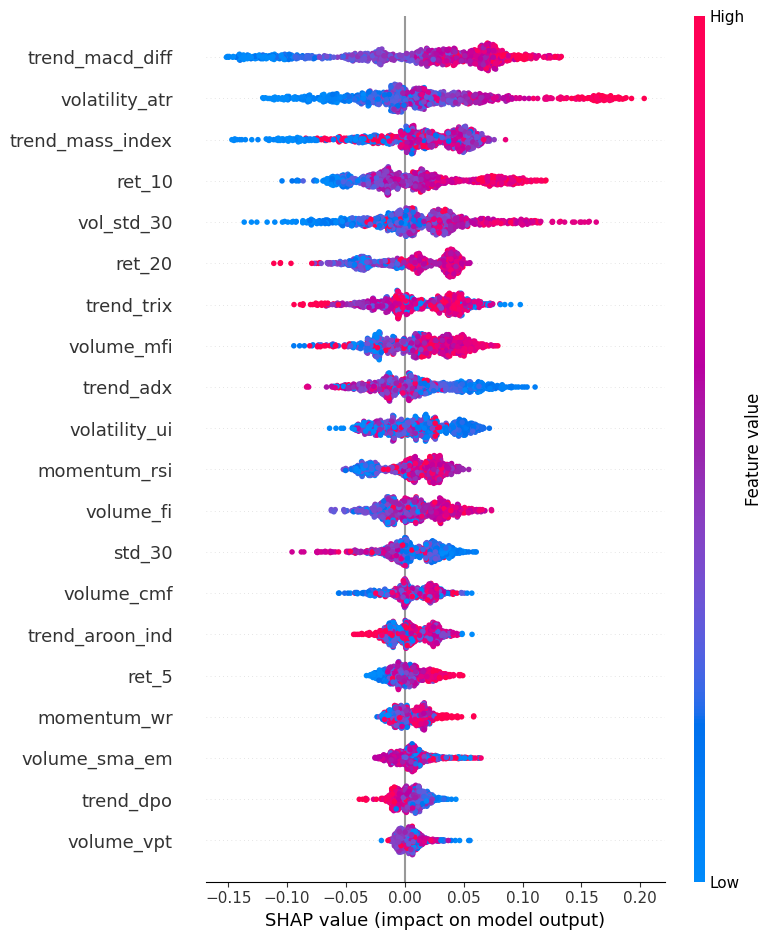

In [67]:
# 다중 클래스 SHAP 결과를 안정적으로 처리하기 위해 배열 형태로 변환
shap_arr = np.array(shap_value)
# 클래스 축이 마지막에 오도록 전치
if shap_arr.ndim == 3 and shap_arr.shape[0] <= 10:
    shap_arr = np.transpose(shap_arr, (1, 2, 0))

# 클래스 수를 계산
n_classes = shap_arr.shape[2] if shap_arr.ndim == 3 else 1
# 각 클래스별 summary plot을 출력
for c in range(n_classes):
    # 다중 클래스인 경우 클래스별 SHAP를 선택
    class_shap = shap_arr[:, :, c] if shap_arr.ndim == 3 else shap_arr
    # 클래스별 요약 플롯을 출력
    shap.summary_plot(class_shap, X_sc, class_names=[f'class {c}'])


In [68]:
# SHAP 배열을 numpy 배열로 변환
shap_arr = np.array(shap_value)
# 클래스 축이 앞에 있을 경우 뒤로 이동
if shap_arr.ndim == 3 and shap_arr.shape[0] <= 10:
    shap_arr = np.transpose(shap_arr, (1, 2, 0))
# 절댓값 평균으로 피처 중요도를 계산
mean_shap = np.mean(np.abs(shap_arr), axis=(0, 2)) if shap_arr.ndim == 3 else np.mean(np.abs(shap_arr), axis=0)
# 중요도 시리즈를 생성하고 정렬
shap_df = pd.Series(mean_shap, index=X_sc.columns).sort_values(ascending=False)
# 결과를 출력
print(shap_df)


trend_macd_diff     0.046413
volatility_atr      0.038977
trend_mass_index    0.034468
trend_trix          0.032068
vol_std_30          0.028592
ret_10              0.026990
volume_mfi          0.022833
ret_20              0.021599
trend_adx           0.021515
volume_cmf          0.021151
volatility_ui       0.020656
volume_fi           0.018114
momentum_rsi        0.016573
std_30              0.016322
trend_aroon_ind     0.013903
ret_5               0.013761
volume_sma_em       0.011749
momentum_wr         0.010405
trend_dpo           0.008138
volume_vpt          0.007569
vol_change_10       0.003227
vol_change_20       0.003210
vol_change_5        0.002994
dtype: float64


In [69]:
output_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')
df_tmp_data.to_pickle(output_file_name)

# 9-4. Model Training

## 1. 환경구성 및 데이터 불러오기

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score, roc_curve

# XGBoost 사용 가능 여부 확인
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

# CPU 코어 수를 병렬 처리에 사용
N_JOBS = os.cpu_count() if os.cpu_count() is not None else 1


In [71]:
"""
Created on Fri Dec  6 19:41:30 2019

@author: sukji
"""
from typing import Callable
import pandas as pd
import numpy as np

from sklearn.metrics import log_loss
from sklearn.model_selection import KFold
from sklearn.base import ClassifierMixin
from sklearn.model_selection import BaseCrossValidator

def ml_get_train_times1(samples_info_sets: pd.Series, test_times: pd.Series) -> pd.Series:
    # pylint: disable=invalid-name
    """
    Advances in Financial Machine Learning, Snippet 7.1, page 106.

    Purging observations in the training set

    This function find the training set indexes given the information on which each record is based
    and the range for the test set.
    Given test_times, find the times of the training observations.

    :param samples_info_sets: (pd.Series) The information range on which each record is constructed from
        *samples_info_sets.index*: Time when the information extraction started.
        *samples_info_sets.value*: Time when the information extraction ended.
    :param test_times: (pd.Series) Times for the test dataset.
    :return: (pd.Series) Training set
    """
    train = samples_info_sets.copy(deep=True)

    start = test_times.min()
    end = test_times.max()

    first = test_times.index[0]
    last = test_times.index[-1]

    df0 = train[(train < first) | (train.index > end)].index  # Train starts within test
    return df0

class PKFold(KFold):
    """
    Extend KFold class to work with labels that span intervals

    The train is purged of observations overlapping test-label intervals
    Test set is assumed contiguous (shuffle=False), w/o training samples in between

    :param n_splits: (int) The number of splits. Default to 3
    :param samples_info_sets: (pd.Series) The information range on which each record is constructed from
        *samples_info_sets.index*: Time when the information extraction started.
        *samples_info_sets.value*: Time when the information extraction ended.
    :param pct_embargo: (float) Percent that determines the embargo size.
    """

    def __init__(self,
                 n_splits: int = 3,
                 samples_info_sets: pd.Series = None,
                 pct_embargo: float = 0.):

        if not isinstance(samples_info_sets, pd.Series):
            raise ValueError('The samples_info_sets param must be a pd.Series')
        super(PKFold, self).__init__(n_splits, shuffle=False, random_state=None)

        self.samples_info_sets = samples_info_sets
        self.pct_embargo = pct_embargo

    # noinspection PyPep8Naming
    def split(self,
              X: pd.DataFrame,
              y: pd.Series = None,
              groups=None):
        """
        The main method to call for the PurgedKFold class

        :param X: (pd.DataFrame) Samples dataset that is to be split
        :param y: (pd.Series) Sample labels series
        :param groups: (array-like), with shape (n_samples,), optional
            Group labels for the samples used while splitting the dataset into
            train/test set.
        :return: (tuple) [train list of sample indices, and test list of sample indices]
        """
        if X.shape[0] != self.samples_info_sets.shape[0]:
            raise ValueError("X and the 'samples_info_sets' series param must be the same length")

        indices: np.ndarray = np.arange(X.shape[0])
        embargo: int = int(X.shape[0] * self.pct_embargo)

        test_ranges: [(int, int)] = [(ix[0], ix[-1] + 1) for ix in np.array_split(np.arange(X.shape[0]), self.n_splits)]
        for start_ix, end_ix in test_ranges:
            test_indices = indices[start_ix:end_ix]

            if end_ix < X.shape[0]:
                end_ix += embargo

            test_times = pd.Series(index=[self.samples_info_sets.index[start_ix]], data=[self.samples_info_sets[end_ix-1]])
            #train_times = ml_get_train_times(self.samples_info_sets, test_times)
            train_times = ml_get_train_times1(self.samples_info_sets, test_times)

            train_indices = []
            for train_ix in train_times:
                train_indices.append(self.samples_info_sets.index.get_loc(train_ix))
            yield np.array(train_indices), test_indices

In [72]:
DATA_PATH = '.'
data_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')

In [73]:
df_data = pd.read_pickle(data_file_name)
df_data['t_value'] = df_data['t_value'].apply(lambda x: x if x == 1 else 0)

In [74]:
df_data['t_value'].value_counts()

1.0    481
0.0    476
Name: t_value, dtype: int64

In [75]:
train_ratio, test_ratio = 0.7, 0.2
n_train = int(np.round(len(df_data) * train_ratio))
n_test = int(np.round(len(df_data) * test_ratio))

In [76]:
X, y = df_data.iloc[:, 5:-1], df_data.iloc[:, -1]

sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [77]:
train_x, test_x, train_y, test_y = X_sc[:n_train, :], X_sc[-n_test:, :], y.iloc[:n_train], y.iloc[-n_test:]

train_x = pd.DataFrame(train_x, index=train_y.index, columns=X.columns)
train_y = pd.Series(train_y, index=train_y.index)
test_x = pd.DataFrame(test_x, index=test_y.index, columns=X.columns)
test_y = pd.Series(test_y, index=test_y.index)

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
train_x = train_x[:1000]
train_y = train_y[:1000]

In [78]:
train_x

,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1.035464,-0.186753,0.065427,0.391695,0.143181,1.474065,0.054076,0.103695,0.930692,-0.078062,...,-0.141586,0.073599,-0.268825,-0.053926,-0.273922,-0.077989,-0.359687,0.617241,-0.335632,0.273404
2018-01-01 00:44:00,1.054026,0.125880,-0.011156,0.814123,0.544363,1.478520,0.017250,0.639945,0.771813,-0.051294,...,0.344922,1.111779,-0.209690,2.237163,-0.263511,0.036043,-0.266915,0.940844,-0.262646,0.291664
2018-01-01 00:45:00,1.042978,-0.023653,0.063195,1.052689,0.218332,1.290057,-0.020738,0.714133,0.598850,-0.015958,...,0.067032,0.544625,-0.124252,0.554780,-0.278339,0.150308,-0.252720,0.942325,-0.237456,0.301886
2018-01-01 00:46:00,1.016133,0.880060,-0.281931,0.928143,1.068429,1.633699,-0.020738,1.434675,0.454452,0.071047,...,0.783648,1.457839,0.168697,2.536405,-0.228841,0.833801,-0.227291,1.672326,-0.022928,0.256716
2018-01-01 00:47:00,0.893440,0.486864,-0.562722,-0.026395,0.862103,1.942977,0.088583,0.921217,0.319680,0.131133,...,-0.191611,-0.257415,-0.080204,0.402681,-0.380178,0.036276,-0.340320,0.454122,-0.018291,0.317671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 11:48:00,-0.401194,-0.656959,0.475561,-1.100167,-0.521844,1.844790,-0.113705,-0.282812,-0.360223,0.287789,...,-0.516289,-0.791551,0.022479,-1.231068,-0.267438,-0.410544,-0.263846,-0.738733,0.586925,0.396518
2018-01-01 11:49:00,-0.183171,-0.400958,0.585458,-1.100167,-0.085709,1.683858,-0.156036,-0.278606,-0.324160,0.297117,...,-0.032056,-0.099431,-0.228529,-0.642497,-0.196571,0.143791,-0.319728,0.911545,0.471733,0.351625
2018-01-01 11:50:00,-0.373766,-0.476587,0.944141,-1.018990,0.064538,1.346547,-0.186992,-0.345393,-0.290502,0.295249,...,-0.155044,-0.272461,-0.248446,-0.201379,-0.192556,-0.961155,-0.121272,1.230046,0.256260,0.119151


## 2. Purged K-fold for Cross-Validation

In [79]:
n_cv = 4
t1 = pd.Series(train_y.index.values, index=train_y.index)
# purged K-Fold
cv = PKFold(n_cv, t1, 0)

## 3. Find the best param for bagging(RandomForest) with grid-search

In [ ]:
# Bagging(RandomForest) 그리드 탐색 파라미터를 정의
bc_params = {
    'n_estimators': [10, 20],
    'max_features': [0.5, 0.8],
    'estimator__max_depth': [5, 10],
    'estimator__max_features': ['sqrt'],
    'estimator__min_samples_leaf': [3, 10],
    'bootstrap_features': [False]
}

# 기반 랜덤포레스트 모델을 생성
rfc = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42, n_jobs=N_JOBS)
# 배깅 분류기를 생성
bag_rfc = BaggingClassifier(estimator=rfc, random_state=42, n_jobs=N_JOBS)
# GridSearchCV 객체를 생성
gs_rfc = GridSearchCV(bag_rfc, bc_params, cv=cv, n_jobs=N_JOBS, verbose=1, scoring='f1')
# GridSearchCV 학습을 수행
gs_rfc.fit(train_x, train_y)
# Bagging 기반 최적 모델을 저장
best_bag_model = gs_rfc.best_estimator_
# 기본 최종 모델명을 설정
best_model_name = 'BaggingRF(CPU)'
# 기본 최종 모델 객체를 설정
gs_rfc_best = best_bag_model

# XGBoost가 설치되어 있으면 GPU 우선 모델을 추가 학습
if XGB_AVAILABLE:
    # GPU 설정으로 XGBoost 모델을 생성
    xgb_model = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        tree_method='hist',
        device='cuda',
        random_state=42,
        n_jobs=N_JOBS
    )

    try:     # GPU 학습 시도
        xgb_model.fit(train_x, train_y)
        best_model_name = 'XGBoost(GPU)'
        gs_rfc_best = xgb_model
    
    except Exception: # GPU 사용이 실패하면 CPU로 자동 전환
        xgb_model = XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            tree_method='hist',
            device='cpu',
            random_state=42,
            n_jobs=N_JOBS
        )
        
        xgb_model.fit(train_x, train_y) # CPU로 재학습        
        best_model_name = 'XGBoost(CPU)'# CPU 모델명으로 갱신       
        gs_rfc_best = xgb_model  # 최종 모델을 CPU XGBoost로 갱신


print(f'Final model candidate: {best_model_name}')


Fitting 4 folds for each of 16 candidates, totalling 64 fits
Final model candidate: XGBoost(GPU)


In [81]:
# 선택된 최종 모델을 전체 학습 구간으로 재학습
gs_rfc_best.fit(train_x, train_y)
# 최종 모델명을 확인 출력
print(f'Final model: {best_model_name}')


Final model: XGBoost(GPU)


In [82]:
pred_y = gs_rfc_best.predict(test_x)  # [1,0,1,0,0,0,0]
prob_y = gs_rfc_best.predict_proba(test_x) # [[0.7,0.3]]

In [ ]:
confusion = confusion_matrix(test_y, pred_y)
accuracy = accuracy_score(test_y, pred_y)
precision = precision_score(test_y, pred_y, zero_division=0)
recall = recall_score(test_y, pred_y, zero_division=0)
f1 = f1_score(test_y, pred_y, zero_division=0)

print('================= confusion matrix ====================')
print(confusion)
print('=======================================================')
print(f'모델:{best_model_name}, 정확도:{accuracy:.4f}, 정밀도:{precision:.4f}, 재현율:{recall:.4f}, F1:{f1:.4f}')


================= confusion matrix ====================
[[64 72]
 [ 9 46]]
모델:XGBoost(GPU), 정확도:0.5759, 정밀도:0.3898, 재현율:0.8364, F1:0.5318


auc:0.7397


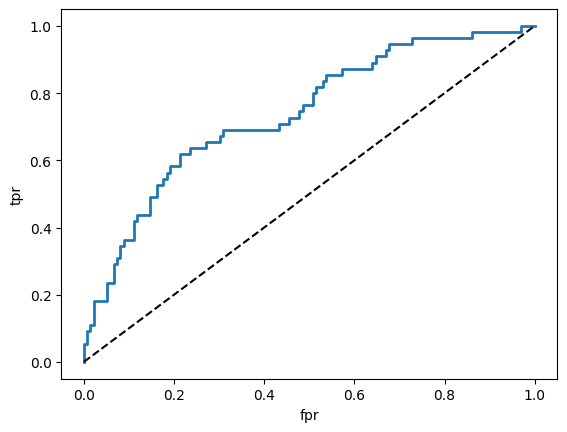

In [ ]:
# ROC 커브 계산
fpr, tpr, thresholds = roc_curve(test_y, prob_y[:, 1])
# AUC 점수를 계산
auc = roc_auc_score(test_y, prob_y[:, 1])

plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('fpr')
plt.ylabel('tpr')
print(f'auc:{auc:.4f}')
